# Expense Line-Item Classifier

**Goal:** predict the general-ledger account (`accountName`) an expense line item should be
booked to, from its text, vendor, and amount.

## Executive summary

The dataset is 4,894 line items spread across 103 accounts, and it is very imbalanced
(the largest account holds 24% of rows; 16 appear only once). The item text carries
almost all of the signal &mdash; when the same item name recurs it is coded to the same
account ~98% of the time &mdash; so the model is deliberately simple: **TF-IDF on the
item text (word + character n-grams) plus a vendor one-hot and a log-scaled amount, fed
to a linear SVM.**

Measured with **5-fold stratified cross-validation** (every transformer refit inside
each fold), the model reaches **90.0% accuracy** (&plusmn;0.9 pp). A single 80/20
stratified hold-out scores **92.1%**, and a deduplicated cross-validation &mdash; which
removes the "same recurring invoice in train and test" effect &mdash; gives a
conservative **89.7%**. The 92% goal is met on the hold-out and missed by about two
points on cross-validation; the gap is genuine category ambiguity (prepaid vs. the
matching expense account, the two IC-clearing variants, two accounts literally named
"Employee Training") and the long tail of rare classes &mdash; not a fixable modelling
choice. The full write-up is in [`reports/report.md`](../reports/report.md).

## Notebook layout

1. Setup
2. Load and validate the data
3. Exploratory analysis
4. Features
5. Model and validation
6. Results and error analysis
7. Save the model
8. Discussion
9. Appendix &mdash; single-item inference

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

# make src/ importable no matter where the notebook is launched from
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src" / "expense_classifier.py").exists()
)
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LinearSVC on this many sparse features usually stops at max_iter, and a few tiny
# classes have fewer rows than the fold count. Both are expected here and change the
# accuracy by < 0.1 pp (verified) -- silence the noise so the output stays readable.
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="The least populated class")
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
)

import expense_classifier as ec

sns.set_theme(style="whitegrid")
FIGURE_DIR = REPO_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_SEED = ec.RANDOM_SEED
ACCURACY_TARGET = 0.92

print("pipeline settings:", ec.ExpenseClassifier())

pipeline settings: ExpenseClassifier(word_ngram=(1, 2), word_max_features=20000, char_ngram=(2, 5), char_max_features=25000, char_min_df=2, numeric_weight=2.0, C=1.0, random_state=42)


## 2. Load and validate the data

In [2]:
raw = ec.load_dataset()
print(f"{len(raw):,} rows, {raw['accountName'].nunique()} accounts")
raw.head(3)

4,894 rows, 103 accounts


,_id,vendorId,itemName,itemDescription,accountId,accountName,itemTotalAmount
0,69606546de1e297ec29890f2,6m656Er7lbi8RYz2ny1J,1225 Business 2Gbps - monthly subscription fee,1225 Business 2Gbps - monthly subscription fee,88AW5nmkLvMe1GthZ6FL,619206 Telephone & Internet,888.00
1,695b5304d09b4ceb96e5288e,VtxikZ7HI6Jwqueemjch,1225-0227 media monitoring,1225-0227 media monitoring,sWG9pai5DiLXaKs6s86G,134004 Prepaid Subscription,17765.00
2,69800f97e85d532c0db71c7e,jdmr9pJ0WHqso4Wh3hCa,0226 Branch,0226 Branch,C0SB5vR0gCikdKjmT8Ep,611202 Online Subscription/Tool,7083.34


In [3]:
# Data-quality checks
account_from_id = raw.groupby("accountId")["accountName"].agg(lambda s: s.mode().iat[0])
checks = {
    "rows": len(raw),
    "missing itemDescription": int((raw["itemDescription"].str.strip() == "").sum()),
    "negative amounts": int((raw["itemTotalAmount"] < 0).sum()),
    "itemName == itemDescription": f"{(raw['itemName'] == raw['itemDescription']).mean():.1%}",
    "duplicate (vendor,name,amount,account) rows": int(
        raw.duplicated(subset=["vendorId", "itemName", "itemTotalAmount", "accountName"]).sum()
    ),
    # accountId is a coarse copy of the label -> excluded from features
    "accountName -> one accountId": f"{(raw.groupby('accountName')['accountId'].nunique() == 1).mean():.0%}",
    "accuracy of guessing account from accountId alone": f"{(raw['accountId'].map(account_from_id) == raw['accountName']).mean():.1%}",
}
for key, value in checks.items():
    print(f"  {key:<48} {value}")

  rows                                             4894
  missing itemDescription                          31
  negative amounts                                 19
  itemName == itemDescription                      83.1%
  duplicate (vendor,name,amount,account) rows      151
  accountName -> one accountId                     100%
  accuracy of guessing account from accountId alone 96.4%


**Takeaways**

- `itemName` and `itemDescription` are identical for 83% of rows, so we combine them and
  keep only one copy when they match.
- A few descriptions are blank and 19 amounts are negative (credits / reversals) &mdash;
  both handled, none dropped.
- ~150 rows are exact duplicates. These are real recurring invoices; we keep them but
  also report a deduplicated cross-validation later so the headline number is not
  flattered by them.
- **`accountId` is excluded.** Every `accountName` maps to one `accountId`, and guessing
  the account from `accountId` alone already scores ~96%. It is assigned *while* coding
  the expense, so it is not available at prediction time &mdash; using it would leak the
  target.

## 3. Exploratory analysis

### 3.1 How the accounts are distributed

accounts                : 103
largest account         : 1,179 rows  (611202 Online Subscription/Tool)
median rows per account  : 15
accounts with 1 row      : 16
accounts with <= 5 rows  : 37  (1.7% of all rows)


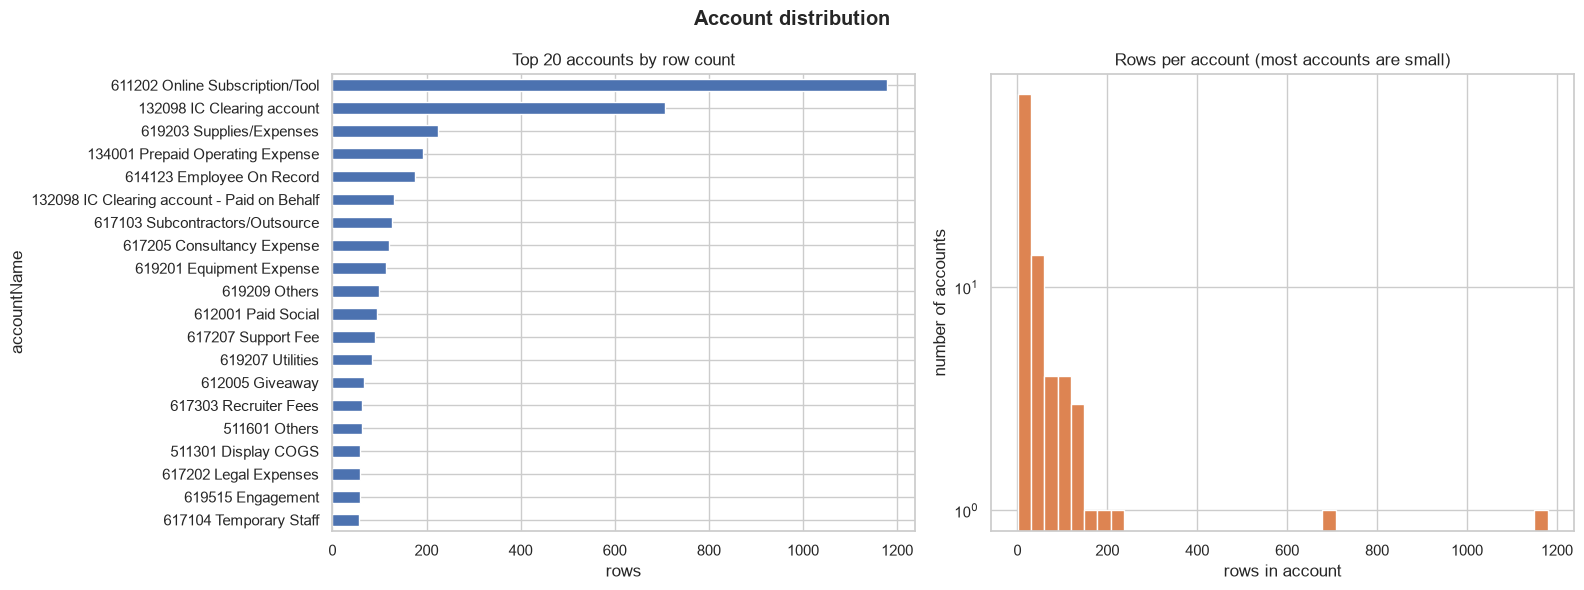

In [4]:
class_counts = raw["accountName"].value_counts()
print(f"accounts                : {len(class_counts)}")
print(f"largest account         : {class_counts.max():,} rows  ({class_counts.idxmax()})")
print(f"median rows per account  : {class_counts.median():.0f}")
print(f"accounts with 1 row      : {(class_counts == 1).sum()}")
print(f"accounts with <= 5 rows  : {(class_counts <= 5).sum()}  "
      f"({raw['accountName'].isin(class_counts[class_counts <= 5].index).mean():.1%} of all rows)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_counts.head(20)[::-1].plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set(title="Top 20 accounts by row count", xlabel="rows")
axes[1].hist(class_counts.values, bins=40, color="#DD8452")
axes[1].set(title="Rows per account (most accounts are small)", xlabel="rows in account",
           ylabel="number of accounts", yscale="log")
fig.suptitle("Account distribution", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

### 3.2 The item text

In [5]:
# ~89% of item names start with a booking-period code like "0725" or "1225-0227".
code_pattern = r"^\d{4}"
range_pattern = r"^\d{4}[-/]\d{4}"
has_code = raw["itemName"].str.match(code_pattern).mean()
has_range = raw["itemName"].str.match(range_pattern).mean()
print(f"item names starting with a period code : {has_code:.1%}")
print(f"           ... with a date range        : {has_range:.1%}")

# A date range is a strong prepaid signal.
is_prepaid = raw["accountName"].str.contains("Prepaid", case=False)
range_when_prepaid = raw.loc[is_prepaid, "itemName"].str.match(range_pattern).mean()
range_otherwise = raw.loc[~is_prepaid, "itemName"].str.match(range_pattern).mean()
print(f"date-range prefix | prepaid rows        : {range_when_prepaid:.1%}")
print(f"date-range prefix | everything else     : {range_otherwise:.1%}")

print("\nExample cleaned text (what the model sees):")
for _, row in raw.sample(4, random_state=RANDOM_SEED).iterrows():
    print(f"  [{row['accountName']}]")
    print(f"   {ec.clean_item_text(row['itemName'], row['itemDescription'])[:90]}")

item names starting with a period code : 88.6%
           ... with a date range        : 5.0%
date-range prefix | prepaid rows        : 51.1%
date-range prefix | everything else     : 2.7%

Example cleaned text (what the model sees):
  [611202 Online Subscription/Tool]
   0126 zoom workplace pro monthly
  [611202 Online Subscription/Tool]
   1225 monthly premium plan contract | 12 month custom premium plan contract
  [151100 Trademarks]
   0424 international registration no 1786082 designating malaysia indonesia vietnam philippi
  [132098 IC Clearing account]
   0724 tw goods demand facebook


The leading codes look like noise but they are **not** &mdash; a date *range*
(`0126-0127 ...`) means the cost is spread over a period, which is exactly what a prepaid
account is. We keep the codes in the text so the character n-grams can pick them up.

### 3.3 The vendor signal

vendors that always map to one account : 62.6%
'always guess the vendor's usual account' accuracy : 73.9%


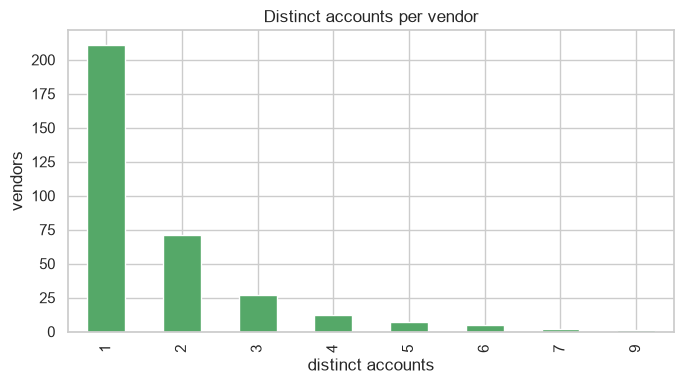

In [6]:
vendor_accounts = raw.groupby("vendorId")["accountName"].nunique()
single = (vendor_accounts == 1).mean()
vendor_majority_oracle = (
    raw["vendorId"].map(raw.groupby("vendorId")["accountName"].agg(lambda s: s.mode().iat[0]))
    == raw["accountName"]
).mean()
print(f"vendors that always map to one account : {single:.1%}")
print(f"'always guess the vendor's usual account' accuracy : {vendor_majority_oracle:.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
vendor_accounts.value_counts().sort_index().head(8).plot.bar(ax=ax, color="#55A868")
ax.set(title="Distinct accounts per vendor", xlabel="distinct accounts", ylabel="vendors")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "vendor_signal.png", dpi=130, bbox_inches="tight")
plt.show()

### 3.4 The amount

min   -1.519500e+04
25%    1.549700e+02
50%    8.452000e+02
75%    3.507140e+03
max    1.618380e+08


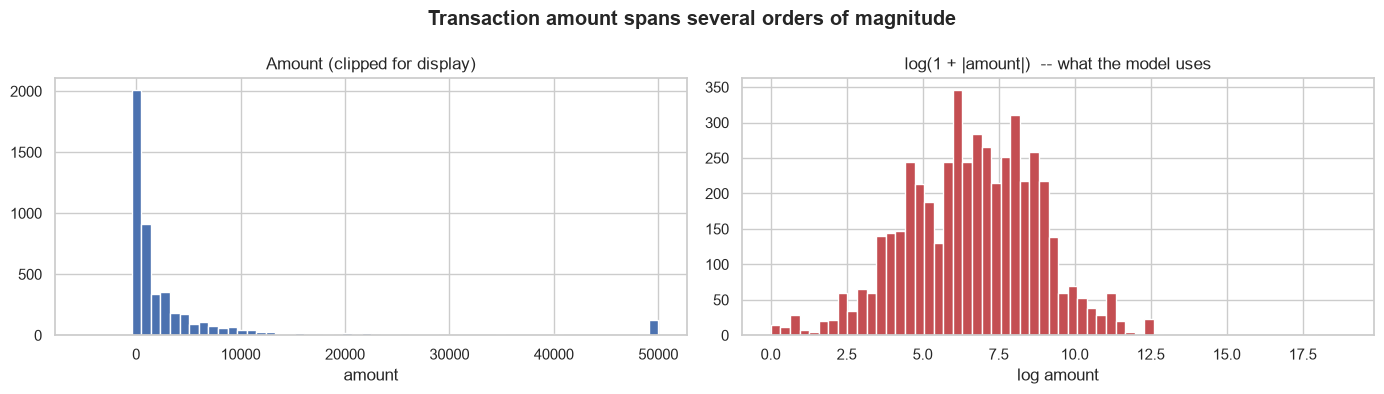

In [7]:
amount = raw["itemTotalAmount"]
print(amount.describe()[["min", "25%", "50%", "75%", "max"]].to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(amount.clip(-5e3, 5e4), bins=60, color="#4C72B0")
axes[0].set(title="Amount (clipped for display)", xlabel="amount")
axes[1].hist(np.log1p(amount.abs().clip(lower=0.01)), bins=60, color="#C44E52")
axes[1].set(title="log(1 + |amount|)  -- what the model uses", xlabel="log amount")
fig.suptitle("Transaction amount spans several orders of magnitude", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "amount_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

### 3.5 What the analysis tells us

| Finding | What we do about it |
|---|---|
| 103 accounts, very imbalanced, 16 singletons | Stratified splits; group singletons for the split; expect macro-F1 << accuracy |
| 37 accounts have <= 5 rows (1.7% of data) | Accept a small accuracy ceiling from these |
| Item text nearly determines the account | Text features (word + char TF-IDF) are the backbone |
| Booking-period codes, date ranges signal prepaid | Keep the codes in the text |
| ~63% of vendors always use one account | Vendor one-hot |
| `accountId` is a coarse copy of the label (~96% predictive) | Excluded from features |
| Wide amount range, some negatives | log transform + sign flag |

## 4. Features

All of this lives in `src/expense_classifier.py` so the notebook, the tests, and
`predict.py` share one code path. `ExpenseClassifier` builds four blocks and stacks them:

| Block | Detail | Why |
|---|---|---|
| Word TF-IDF | 1&ndash;2 grams, 20k features, sublinear | keywords: *subscription*, *retainer*, *audit fee* |
| Char TF-IDF | 2&ndash;5 grams (`char_wb`), 25k features | short / coded text, partial-word matches |
| Vendor one-hot | every vendor seen in training | vendor identity is deterministic for most rows |
| Amount | log-amount, sign flag, date-range flag | separates prepaid / credit / expense |

The exact settings are the defaults on `ExpenseClassifier` (printed in the Setup cell).

In [8]:
# One fitted example, to see the feature matrix shape
demo = ec.ExpenseClassifier().fit(raw)
X_demo = demo._transform(raw.head(5))
print(f"feature matrix for 5 rows : {X_demo.shape}")
print(f"  word  : {len(demo.word_vectorizer.vocabulary_):>6}")
print(f"  char  : {len(demo.char_vectorizer.vocabulary_):>6}")
print(f"  vendor: {len(demo.vendor_vocab):>6}")
print(f"  amount: {'3':>6}")

feature matrix for 5 rows : (5, 31287)
  word  :  14152
  char  :  16795
  vendor:    337
  amount:      3


## 5. Model and validation

**Why a linear SVM:** on sparse TF-IDF it is a strong, fast, well-understood baseline;
it handles 40k+ features and 103 classes in seconds; and its coefficients are readable,
which matters for a finance audience. Complement Naive Bayes, logistic regression,
gradient boosting, an exact-match retrieval layer, and stacked ensembles were all tried
&mdash; none beat the plain linear SVM on cross-validation, so we keep the simple model.

**Validation:** 5-fold stratified cross-validation is the headline metric. Every
transformer (both vectorizers, the scaler, the vendor vocabulary) is refit **inside**
each fold, so nothing leaks from validation rows into training.

In [9]:
cv = ec.cross_val_predict(raw, n_splits=5, random_state=RANDOM_SEED)
cv_acc = ec.fold_accuracies(cv)
print("5-fold stratified CV")
for i, a in enumerate(cv_acc, 1):
    print(f"  fold {i}: {a:.4f}")
print(f"  ----\n  mean {cv_acc.mean():.4f}   std {cv_acc.std():.4f}")
print(f"  target {ACCURACY_TARGET:.0%}: {'met' if cv_acc.mean() >= ACCURACY_TARGET else 'not quite (' + format(cv_acc.mean(), '.1%') + ')'}")

5-fold stratified CV
  fold 1: 0.8897
  fold 2: 0.9091
  fold 3: 0.9019
  fold 4: 0.9111
  fold 5: 0.8906
  ----
  mean 0.9005   std 0.0090
  target 92%: not quite (90.0%)


In [10]:
# Conservative check: collapse identical recurring invoices, then cross-validate again
cv_dedup = ec.cross_val_predict(raw, n_splits=5, random_state=RANDOM_SEED, dedup=True)
dedup_acc = ec.fold_accuracies(cv_dedup)
print(f"deduplicated 5-fold CV ({len(cv_dedup):,} unique rows): "
      f"{dedup_acc.mean():.4f}  std {dedup_acc.std():.4f}")

deduplicated 5-fold CV (4,743 unique rows): 0.8969  std 0.0139


In [11]:
# Single 80/20 stratified hold-out (the other protocol the brief allows)
strat = ec._stratify_labels(raw["accountName"])
train_idx, test_idx = train_test_split(
    np.arange(len(raw)), test_size=0.20, random_state=RANDOM_SEED, stratify=strat
)
holdout_model = ec.ExpenseClassifier().fit(raw.iloc[train_idx])
holdout_pred = holdout_model.predict(raw.iloc[test_idx])
holdout_true = raw.iloc[test_idx]["accountName"].to_numpy()
holdout_acc = accuracy_score(holdout_true, holdout_pred)
print(f"80/20 hold-out accuracy: {holdout_acc:.4f}")

80/20 hold-out accuracy: 0.9213


## 6. Results and error analysis

### 6.1 Headline metrics (from the 5-fold out-of-fold predictions)

In [12]:
y_true, y_pred = cv["true"].to_numpy(), cv["predicted"].to_numpy()
summary = {
    "Accuracy (5-fold CV)":       cv_acc.mean(),
    "Accuracy (dedup CV)":        dedup_acc.mean(),
    "Accuracy (80/20 hold-out)":  holdout_acc,
    "Macro precision":            precision_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro recall":               recall_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro F1":                   f1_score(y_true, y_pred, average="macro", zero_division=0),
    "Weighted F1":                f1_score(y_true, y_pred, average="weighted", zero_division=0),
}
for name, value in summary.items():
    print(f"  {name:<28} {value:.4f}")

  Accuracy (5-fold CV)         0.9005
  Accuracy (dedup CV)          0.8969
  Accuracy (80/20 hold-out)    0.9213
  Macro precision              0.6833
  Macro recall                 0.6715
  Macro F1                     0.6728
  Weighted F1                  0.8975


### 6.2 Which accounts work, which don't

Best (high F1, decent support):
                                  precision  recall   f1  support
511606 Audience Extension               1.0     1.0  1.0       42
511102 External Commission              1.0     1.0  1.0       41
223001 Salaries Payable                 1.0     1.0  1.0       28
131020 Unbilled receivables             1.0     1.0  1.0       25
619202 Cleaning                         1.0     1.0  1.0       23
611101 Cloud server - AWS               1.0     1.0  1.0       21
612031 Paid Content                     1.0     1.0  1.0       13
617101 Customer Support - Others        1.0     1.0  1.0       13

Weakest (support >= 5):
                                precision    recall        f1  support
151101 Cost                      0.705882  0.705882  0.705882       17
617208 Others                    0.666667  0.750000  0.705882        8
612016 Collateral                0.620690  0.720000  0.666667       25
612032 Key Opinion Leader        0.625000  0.625000  0.625000    

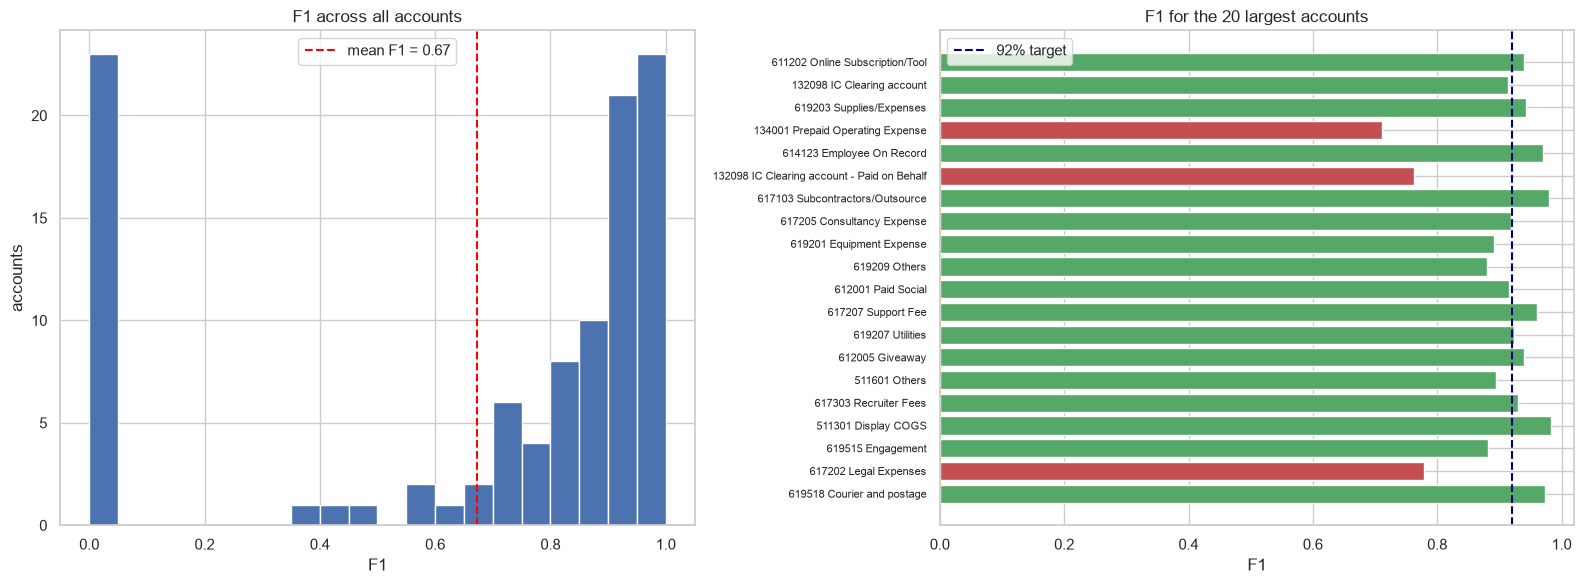

In [13]:
report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
per_class = (
    pd.DataFrame({k: v for k, v in report.items()
                  if k not in ("accuracy", "macro avg", "weighted avg")}).T
    .rename(columns={"f1-score": "f1"})
    .astype({"precision": float, "recall": float, "f1": float, "support": int})
    .sort_values(["f1", "support"], ascending=False)
)
print("Best (high F1, decent support):")
print(per_class[per_class.support >= 10].head(8).to_string())
print("\nWeakest (support >= 5):")
print(per_class[per_class.support >= 5].tail(8).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(per_class["f1"], bins=20, color="#4C72B0")
axes[0].axvline(per_class["f1"].mean(), color="red", ls="--",
                label=f"mean F1 = {per_class['f1'].mean():.2f}")
axes[0].set(title="F1 across all accounts", xlabel="F1", ylabel="accounts")
axes[0].legend()
top = per_class.sort_values("support", ascending=False).head(20)
axes[1].barh(top.index[::-1], top["f1"][::-1],
             color=["#C44E52" if v < 0.8 else "#55A868" for v in top["f1"][::-1]])
axes[1].axvline(ACCURACY_TARGET, color="navy", ls="--", label="92% target")
axes[1].set(title="F1 for the 20 largest accounts", xlabel="F1", xlim=(0, 1.02))
axes[1].tick_params(axis="y", labelsize=8)
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "per_class_f1.png", dpi=130, bbox_inches="tight")
plt.show()

### 6.3 Confusion matrix &mdash; 12 largest accounts

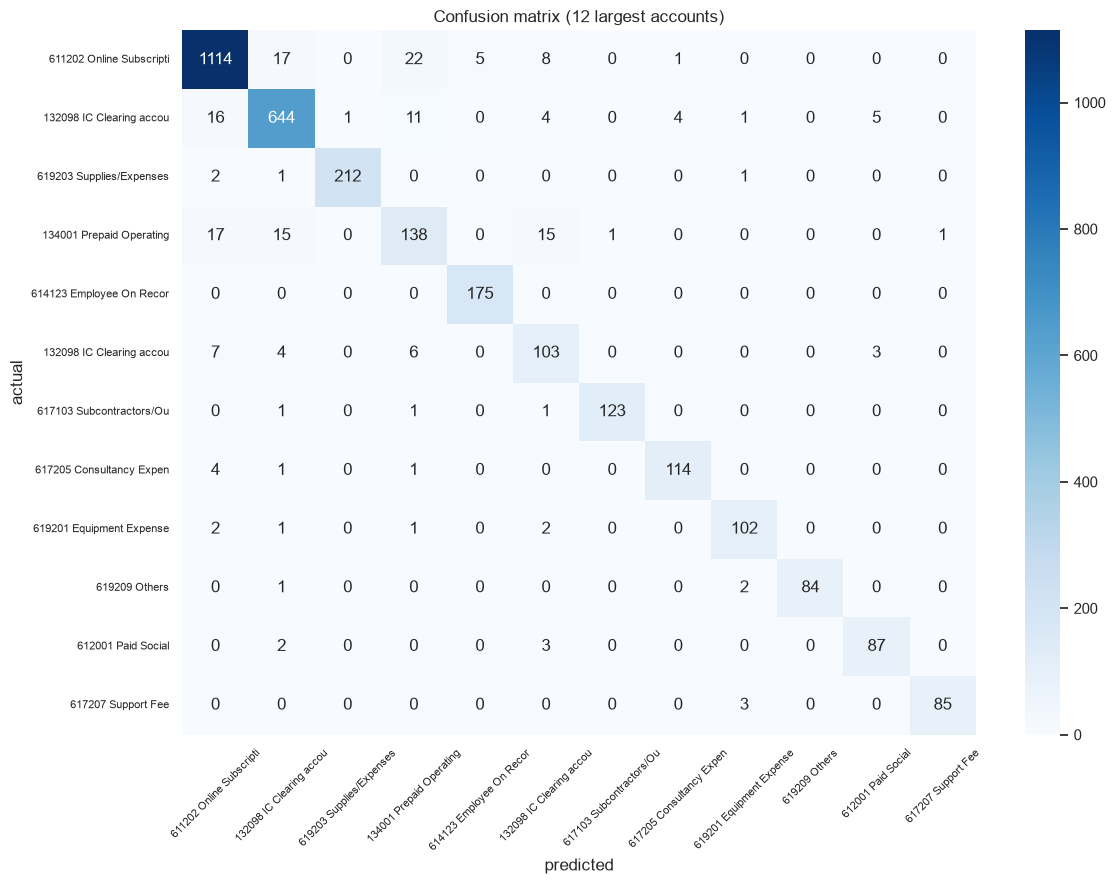

In [14]:
top12 = pd.Series(y_true).value_counts().head(12).index.tolist()
mask = pd.Series(y_true).isin(top12).to_numpy()
cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top12)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=[t[:24] for t in top12], yticklabels=[t[:24] for t in top12])
ax.set(title="Confusion matrix (12 largest accounts)", xlabel="predicted", ylabel="actual")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=130, bbox_inches="tight")
plt.show()

In [15]:
# Most common mistakes
errors = pd.DataFrame({"actual": y_true, "predicted": y_pred})
errors = errors[errors.actual != errors.predicted]
print(f"errors: {len(errors):,} / {len(cv):,}  ({len(errors) / len(cv):.1%})\n")
print("Top confusion pairs (actual -> predicted):")
print(errors.groupby(["actual", "predicted"]).size().sort_values(ascending=False).head(10).to_string())

errors: 487 / 4,894  (10.0%)

Top confusion pairs (actual -> predicted):
actual                            predicted                                  
611202 Online Subscription/Tool   134001 Prepaid Operating Expense               22
                                  132098 IC Clearing account                     17
134001 Prepaid Operating Expense  611202 Online Subscription/Tool                17
132098 IC Clearing account        611202 Online Subscription/Tool                16
134001 Prepaid Operating Expense  132098 IC Clearing account                     15
                                  132098 IC Clearing account - Paid on Behalf    15
132098 IC Clearing account        134001 Prepaid Operating Expense               11
611202 Online Subscription/Tool   132098 IC Clearing account - Paid on Behalf     8
134004 Prepaid Subscription       611202 Online Subscription/Tool                 7
619209 Others                     619207 Utilities                                7


The mistakes are concentrated and sensible: **prepaid vs. the matching expense account**
(same vendor, same wording, differs only by whether the cost is spread over time), and
the two **IC-clearing** variants. These are cases where even a human coder needs the
invoice context, not just the line item.

## 7. Save the model

In [16]:
final_model = ec.ExpenseClassifier().fit(raw)
saved_to = final_model.save()
print(f"saved -> {saved_to.relative_to(REPO_ROOT)}")

reload = ec.ExpenseClassifier.load(saved_to)
print("reload check:", reload.predict_one("Zoom annual subscription", amount=1200)[0])

saved -> models\expense_classifier.joblib
reload check: ('611202 Online Subscription/Tool', 0.026967770557671116)


## 8. Discussion

**Strengths**

- Simple and fast: one linear model, a few thousand features, trains in seconds, and
  every coefficient can be inspected and explained to a finance team.
- Honest evaluation: transformers refit inside every fold, plus a deduplicated CV so
  recurring invoices don't inflate the score.
- Reproducible: fixed seed, one shared code path, `python src/predict.py --self-test`.

**Limitations**

- **Rare accounts.** 16 accounts have a single example and 37 have <= 5; the model
  cannot learn them and they cap macro-F1.
- **Prepaid vs. expense** confusion needs invoice-level context the line item doesn't carry.
- **New vendors** get an all-zero vendor block and lean entirely on text.
- **Label noise.** Repeated item names disagree on the account ~1.5% of the time, so a
  slice of the "ground truth" is itself inconsistent.
- **Static.** New accounts and vendors need a periodic retrain.

**With more time**

- **Calibrated probabilities** (`CalibratedClassifierCV`, or a logistic model) so the
  confidence score is a true probability and the review threshold below is meaningful.
- A vendor + line-item rules table for the ~30% of rows that are unambiguous recurring
  invoices, with the model handling the rest.
- Sentence embeddings instead of TF-IDF for the more free-form descriptions.
- Hierarchical classification: predict the account family (first digit) first, then the
  account within it.

**Deploying it**

- Auto-post only when the (calibrated) confidence clears a threshold; queue the rest for
  a finance reviewer.
- Log model version + predicted account + score with every line for audit.
- Watch accuracy on new invoices monthly; retrain when it drops below its cross-validated
  baseline or when new accounts/vendors appear.

## 9. Appendix &mdash; single-item inference

`predict_one` returns the top-k accounts with a *relative* score (softmax over the SVM
margins across 103 classes). The absolute number is small &mdash; that is expected with
this many classes &mdash; but the top account sits clearly ahead of the runners-up when
the model is confident, and close to them when it is not.

In [17]:
examples = [
    ("Zoom Workplace Pro monthly", 99.0),
    ("0126-0127 Group-IB annual license renewal", 24000.0),
    ("Legal opinion on shareholder matter", 5000.0),
    ("Recruiter placement fee - senior engineer", 3500.0),
    ("AWS October usage", 8000.0),
]
for name, amount in examples:
    ranked = final_model.predict_one(name, amount=amount)
    print(f"  {name}")
    for account, score in ranked:
        print(f"      {score:6.1%}  {account}")
    print()

  Zoom Workplace Pro monthly
        3.4%  611202 Online Subscription/Tool
        1.1%  619206 Telephone & Internet
        1.1%  617101 Customer Support - Others

  0126-0127 Group-IB annual license renewal
        4.9%  134001 Prepaid Operating Expense
        1.5%  134004 Prepaid Subscription
        1.3%  132098 IC Clearing account - Paid on Behalf

  Legal opinion on shareholder matter
        3.8%  617202 Legal Expenses
        1.1%  617205 Consultancy Expense
        1.1%  151101 Trademarks - Cost

  Recruiter placement fee - senior engineer
        1.3%  617104 Temporary Staff
        1.2%  132098 IC Clearing account
        1.2%  617103 Subcontractors/Outsource

  AWS October usage
        1.7%  611101 Cloud server - AWS
        1.4%  619502 Bank Charges
        1.2%  612031 Paid Content

